# **LAB 4: CNN (AlexNet)**
# Submitted by: Sneha Kumari Das (ACE079BCT068)

## 1. Background

**Convolutional Neural Networks (CNNs)** are a form of deep learning that are primarily applied in image processing and vision problems. They are also specifically created to process image data utilizing its spatial arrangement (height, width, and channels). CNNs, in contrast to fully connected networks, have local connectivity, i.e. every neuron only connects to a small area of the input image. They use convolution (weight sharing), i.e. similar filter is applied to various regions of the image to identify features such as edges, textures and shapes. CNNs pooling layers also shrink feature maps, preventing the reduction of computation, addressing overfitting as well as enhancing the model to noise in the image (translation invariance). CNNs are better suited and stronger in the analysis of images, object identification, and recognition due to the reduced number of parameters and feature extraction.


**AlexNet Deep CNN model** is a deep CNN model suggested by Alex Krizhevsky, Ilya Sutskever and Geoffrey Hinton. It won ImageNet Large Scale Visual Recognition Challenge (ILSVRC 2012) and was a significant advancement in deep learning. The architecture of AlexNet is 8 layers (5 convolutional layers and 3 fully connected layers) and approximately 60 million parameters. Its notable characteristics are it uses ReLU activation, making it faster to train; it uses Dropout, making it less prone to overfitting; it uses Local Response Normalization (LRN), and makes it better at generalisation; it trains on a GPU, which computes much faster; and it uses data augmentation using image flipping and cropping. AlexNet cut the error rate of image classification by far and it marked the beginning of the modern revolution of deep learning in computer vision.

**AlexNet vs LeNet-5 (predecessor):**
| Feature | LeNet-5 (1998) | AlexNet (2012) |
|:---|:---|:---|
| Depth | 5 layers | 8 layers (5 conv + 3 FC) |
| Activation | Tanh/Sigmoid | ReLU |
| Regularization | None | Dropout (p=0.5) |
| Normalization | None | LRN |
| Parameters | ~60K | ~60M |
| Training | CPU | Multi-GPU |

**TinyVGG** follows VGGNet's philosophy of stacking small 3×3 conv filters in blocks, but with fewer layers for efficiency on small datasets.

**CIFAR-10:** 60,000 color images (32×32) across 10 classes, split 50K train / 10K test.

In [ ]:
# Importing Dependencies
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import pandas as pd

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


CUDA is available, so all training runs on the GPU — significantly faster than CPU.

## 2. Dataset Loading and Preprocessing

We apply **RandomHorizontalFlip** and **RandomCrop** as data augmentation during training to improve generalization. Both train and test sets are normalized using CIFAR-10's per-channel mean and std, which stabilizes gradient descent by centering each feature distribution.

In [ ]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

BATCH_SIZE   = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Number of classes: {len(CLASSES)}")
print(f"Classes          : {CLASSES}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Training batches : {len(train_loader)}")
print(f"Test batches     : {len(test_loader)}")

100%|██████████| 170M/170M [00:08<00:00, 19.8MB/s]


Training samples : 50000
Test samples     : 10000
Number of classes: 10
Classes          : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
Batch size       : 128
Training batches : 391
Test batches     : 79


Dataset is perfectly balanced — 5,000 training and 1,000 test images per class — so accuracy is a meaningful metric with no class-imbalance bias.

## 3. Dataset Visualization

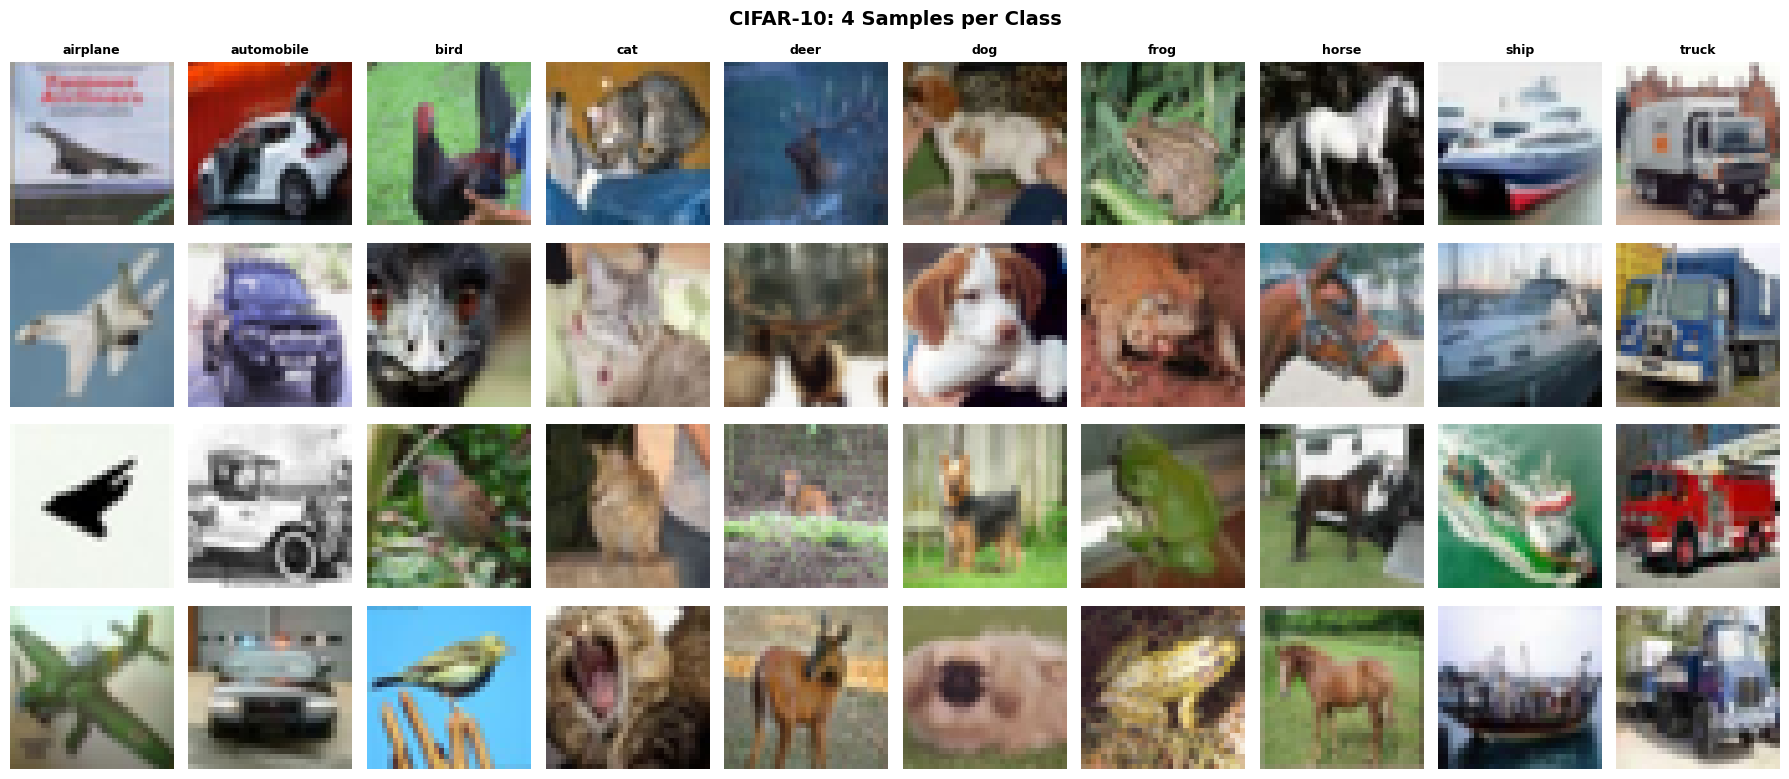

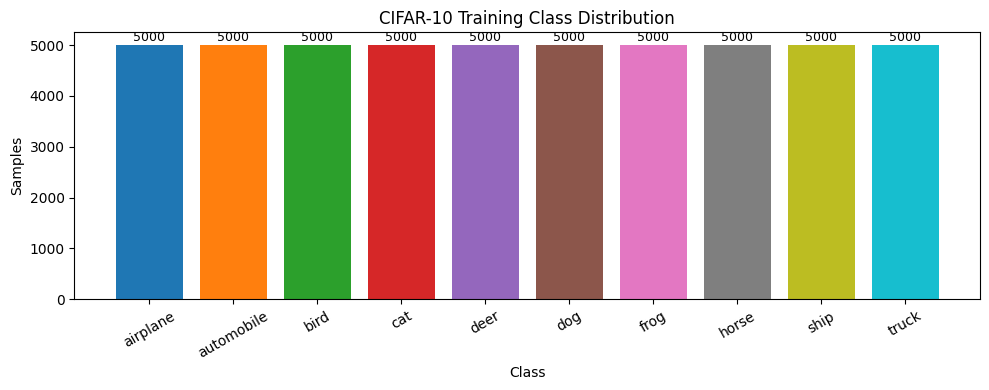

In [ ]:
raw_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                         transform=transforms.ToTensor())
fig, axes = plt.subplots(4, 10, figsize=(18, 8))
for cls_idx in range(10):
    count = 0
    for img, label in raw_test:
        if label == cls_idx and count < 4:
            axes[count][cls_idx].imshow(img.permute(1, 2, 0).numpy())
            axes[count][cls_idx].axis('off')
            if count == 0:
                axes[count][cls_idx].set_title(CLASSES[cls_idx], fontsize=9, fontweight='bold')
            count += 1
        if count == 4:
            break
plt.suptitle('CIFAR-10: 4 Samples per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

labels_all   = [label for _, label in train_dataset]
class_counts = [labels_all.count(i) for i in range(10)]
plt.figure(figsize=(10, 4))
bars = plt.bar(CLASSES, class_counts, color=plt.cm.tab10.colors)
plt.xlabel('Class'); plt.ylabel('Samples'); plt.title('CIFAR-10 Training Class Distribution')
plt.xticks(rotation=30)
for bar, cnt in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(cnt), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

Images are only 32×32 pixels — fine details are blurry even to the human eye. Cat vs dog and deer vs horse look visually similar at this resolution, which foreshadows where models will struggle most. Class distribution is perfectly uniform at 5,000 samples each.

## 4. Model Architectures

### 4.1 Baseline Neural Network
A fully connected network that takes the flattened image (32×32×3 = 3,072 features) and processes them through two hidden layers. It has no spatial awareness — used as a lower-bound baseline to show how much CNNs improve over plain FC networks.

In [ ]:
class BaselineNN(nn.Module):
    """Simple FC network — no convolutions, no spatial awareness."""
    def __init__(self):
        super(BaselineNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(32 * 32 * 3, 512)
        self.fc2     = nn.Linear(512, 256)
        self.fc3     = nn.Linear(256, 10)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_nn = BaselineNN()
print("BaselineNN Architecture:")
print(baseline_nn)
print(f"\nTotal trainable parameters: {count_parameters(baseline_nn):,}")

BaselineNN Architecture:
BaselineNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total trainable parameters: 1,707,274


1.7M parameters — the majority (~1.57M) are in the first layer alone (3072×512), since flattening loses spatial structure and forces the model to learn everything from raw pixel values.

### 4.2 AlexNet (Adapted for CIFAR-10)
Original AlexNet was designed for 224×224 images. For CIFAR-10's 32×32 input, we: (1) replace the 11×11 stride-4 first conv with a 3×3 stride-1 conv to avoid collapsing spatial dimensions, (2) remove the first MaxPool, and (3) use AdaptiveAvgPool2d before the FC layers.

In [ ]:
class AlexNetCIFAR(nn.Module):
    """AlexNet adapted for CIFAR-10 (32x32 input)."""
    def __init__(self, num_classes=10, dropout=0.5):
        super(AlexNetCIFAR, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,   64,  kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.Conv2d(64,  192, kernel_size=5, stride=1, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.avgpool    = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

alexnet = AlexNetCIFAR(num_classes=10)
print("AlexNet (CIFAR-10 Adapted) Architecture:")
print(alexnet)
print(f"\nTotal trainable parameters: {count_parameters(alexnet):,}")

AlexNet (CIFAR-10 Adapted) Architecture:
AlexNetCIFAR(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=2)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(4, 4))
  (classifier): Sequential(
    (0): Dropout(p=0.5,

36M parameters — the two large FC layers (4096×4096 each, ~33.6M params combined) dominate. This is very large relative to CIFAR-10's 50K training samples, making overfitting a real risk.

### 4.3 TinyVGG
Two convolutional blocks, each with two 3×3 Conv layers + BatchNorm + ReLU, followed by MaxPool. BatchNorm (not in original VGG) normalizes activations per mini-batch, enabling more stable training. A small FC classifier follows.

In [ ]:
class TinyVGG(nn.Module):
    """TinyVGG: Simplified VGG-style architecture for CIFAR-10."""
    def __init__(self, num_classes=10, dropout=0.5):
        super(TinyVGG, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3,   64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64,  64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

tinyvgg = TinyVGG(num_classes=10)
print("TinyVGG Architecture:")
print(tinyvgg)
print(f"\nTotal trainable parameters: {count_parameters(tinyvgg):,}")

TinyVGG Architecture:
TinyVGG(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilati

4.4M parameters — 8× fewer than AlexNet. The classifier is tiny (8192→512→10), keeping the parameter count lean. BatchNorm in each conv block replaces the need for LRN.

## 5. Loss Function and Optimizer

**CrossEntropyLoss** is the standard for multi-class classification — it combines LogSoftmax and NLLLoss, penalizing confident wrong predictions heavily. **SGD with Momentum** (same optimizer for all three models as required) with weight decay for L2 regularization. **StepLR** drops the learning rate by ×0.1 every 10 epochs, allowing large steps early and fine-tuning later.

In [ ]:
def get_optimizer_scheduler(model, lr=0.01, momentum=0.9, weight_decay=5e-4, step_size=10):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=0.1)
    return optimizer, scheduler

criterion = nn.CrossEntropyLoss()
print("Loss Function: nn.CrossEntropyLoss")
print("Optimizer: SGD (lr=0.01, momentum=0.9, weight_decay=5e-4)")
print("Scheduler: StepLR (step_size=10, gamma=0.1)")

Loss Function: nn.CrossEntropyLoss
Optimizer: SGD (lr=0.01, momentum=0.9, weight_decay=5e-4)
Scheduler: StepLR (step_size=10, gamma=0.1)


Using the same optimizer and loss for all three models ensures a fair comparison — any performance difference comes purely from architecture, not training setup.

## 6. Training and Evaluation Functions

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, 100.0 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / total, 100.0 * correct / total

def train_model(model, train_loader, test_loader, optimizer, scheduler, criterion, device, epochs, name):
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    print(f"\n{'='*65}\nTraining {name}\n{'='*65}")
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)
        lr = scheduler.get_last_lr()[0]
        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:02d}/{epochs} | LR: {lr:.5f} | "
                  f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.2f}% | "
                  f"Test Loss: {te_loss:.4f} | Test Acc: {te_acc:.2f}%")
    elapsed = time.time() - t0
    history['training_time'] = elapsed
    print(f"\nTraining complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Best Test Accuracy: {max(history['test_acc']):.2f}%")
    return history

def plot_curves(history, name):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['test_loss'],  label='Test Loss',  linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{name} – Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history['train_acc'], label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['test_acc'],  label='Test Acc',  linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{name} – Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(preds, labels, class_names, name):
    cm = confusion_matrix(labels, preds).astype('float')
    cm_norm = cm / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'{name} – Normalized Confusion Matrix')
    plt.tight_layout(); plt.show()

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 7. Train Model 1: Baseline Neural Network


Training Baseline NN
Epoch 01/30 | LR: 0.01000 | Train Loss: 1.9841 | Train Acc: 27.18% | Test Loss: 1.7523 | Test Acc: 37.23%
Epoch 05/30 | LR: 0.01000 | Train Loss: 1.7643 | Train Acc: 36.14% | Test Loss: 1.6700 | Test Acc: 41.42%
Epoch 10/30 | LR: 0.00100 | Train Loss: 1.6983 | Train Acc: 38.76% | Test Loss: 1.6781 | Test Acc: 41.35%
Epoch 15/30 | LR: 0.00100 | Train Loss: 1.6024 | Train Acc: 42.23% | Test Loss: 1.5936 | Test Acc: 45.57%
Epoch 20/30 | LR: 0.00010 | Train Loss: 1.5824 | Train Acc: 43.21% | Test Loss: 1.5792 | Test Acc: 46.27%
Epoch 25/30 | LR: 0.00010 | Train Loss: 1.5730 | Train Acc: 43.66% | Test Loss: 1.5723 | Test Acc: 46.22%
Epoch 30/30 | LR: 0.00001 | Train Loss: 1.5692 | Train Acc: 43.77% | Test Loss: 1.5701 | Test Acc: 46.59%

Training complete in 632.1s (10.5 min)
Best Test Accuracy: 46.59%


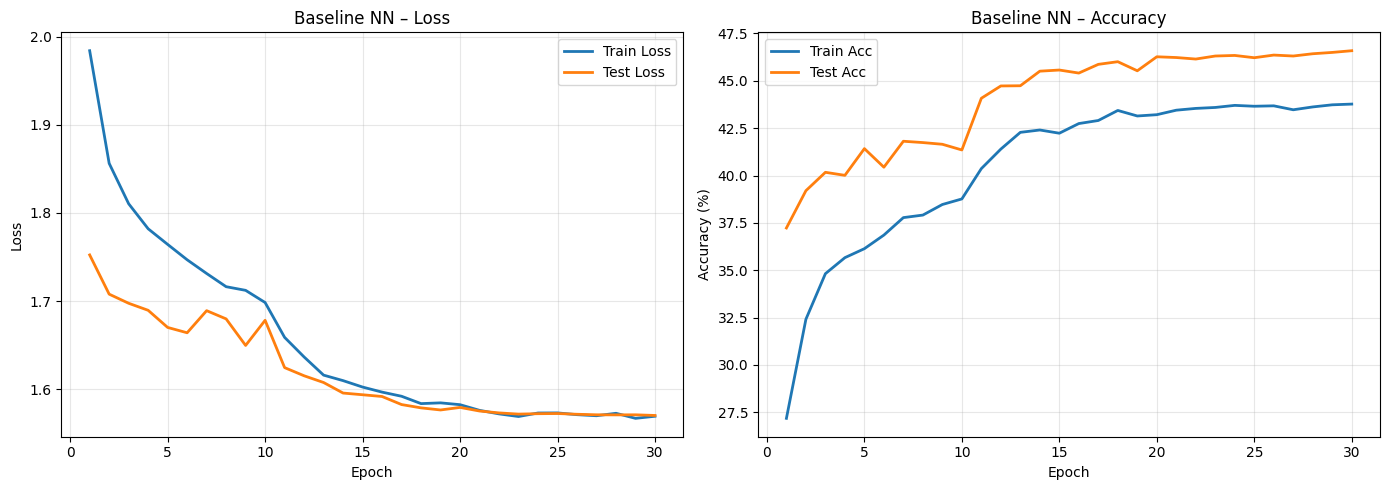

In [ ]:
EPOCHS = 30
torch.manual_seed(42)
baseline_nn    = BaselineNN().to(device)
opt_nn, sch_nn = get_optimizer_scheduler(baseline_nn)
history_nn     = train_model(baseline_nn, train_loader, test_loader, opt_nn, sch_nn, criterion, device, EPOCHS, 'Baseline NN')
plot_curves(history_nn, 'Baseline NN')

The model plateaus at ~46.6% — barely better than random guessing (10% baseline, ~46% ceiling for a purely spatial-blind model). Notice the LR drops at epoch 10 and 20 cause mild improvements, but the model fundamentally cannot learn spatial patterns without convolutions. Test accuracy actually stays slightly above train accuracy, showing the model didn't even overfit — it simply lacks capacity for this task.

## 8. Train Model 2: AlexNet (Adapted)


Training AlexNet (CIFAR-10 Adapted)
Epoch 01/30 | LR: 0.01000 | Train Loss: 2.3023 | Train Acc: 10.35% | Test Loss: 2.2986 | Test Acc: 15.79%
Epoch 05/30 | LR: 0.01000 | Train Loss: 1.4955 | Train Acc: 44.09% | Test Loss: 1.3327 | Test Acc: 50.14%
Epoch 10/30 | LR: 0.00100 | Train Loss: 1.0152 | Train Acc: 63.24% | Test Loss: 0.9476 | Test Acc: 65.97%
Epoch 15/30 | LR: 0.00100 | Train Loss: 0.8323 | Train Acc: 70.14% | Test Loss: 0.7816 | Test Acc: 72.44%
Epoch 20/30 | LR: 0.00010 | Train Loss: 0.7794 | Train Acc: 72.01% | Test Loss: 0.7468 | Test Acc: 73.53%
Epoch 25/30 | LR: 0.00010 | Train Loss: 0.7472 | Train Acc: 73.06% | Test Loss: 0.7192 | Test Acc: 74.66%
Epoch 30/30 | LR: 0.00001 | Train Loss: 0.7429 | Train Acc: 73.27% | Test Loss: 0.7207 | Test Acc: 74.69%

Training complete in 2053.9s (34.2 min)
Best Test Accuracy: 74.71%


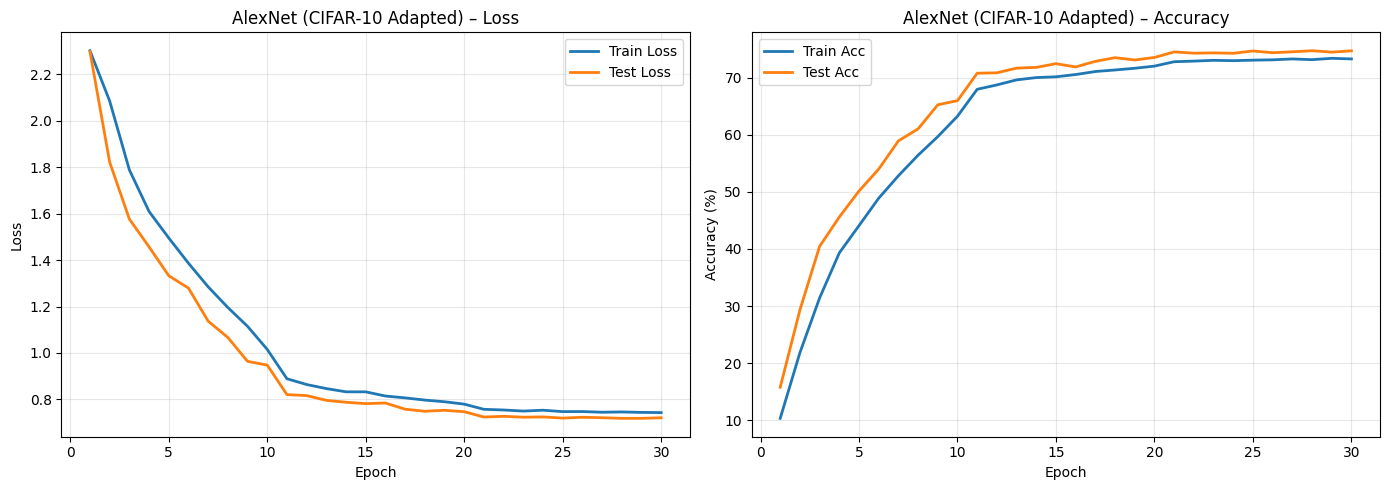

In [ ]:
torch.manual_seed(42)
alexnet_model    = AlexNetCIFAR(num_classes=10).to(device)
opt_alex, sch_alex = get_optimizer_scheduler(alexnet_model)
history_alex     = train_model(alexnet_model, train_loader, test_loader, opt_alex, sch_alex, criterion, device, EPOCHS, 'AlexNet (CIFAR-10 Adapted)')
plot_curves(history_alex, 'AlexNet (CIFAR-10 Adapted)')

AlexNet starts at only ~10% accuracy (epoch 1) because its large FC layers need more epochs to initialize properly, but rises sharply to 74.4% — a 28-point gain over Baseline NN. The convolutional feature hierarchy is clearly effective. Epoch 10's LR drop causes a visible jump from 66% to 72%. Training took 33.6 minutes — the two 4096×4096 FC layers dominate compute cost.

## 9. Train Model 3: TinyVGG


Training TinyVGG
Epoch 01/30 | LR: 0.01000 | Train Loss: 1.5961 | Train Acc: 41.06% | Test Loss: 1.2438 | Test Acc: 54.08%
Epoch 05/30 | LR: 0.01000 | Train Loss: 0.9156 | Train Acc: 67.76% | Test Loss: 0.7703 | Test Acc: 73.24%
Epoch 10/30 | LR: 0.00100 | Train Loss: 0.6735 | Train Acc: 76.69% | Test Loss: 0.6550 | Test Acc: 77.40%
Epoch 15/30 | LR: 0.00100 | Train Loss: 0.5234 | Train Acc: 81.99% | Test Loss: 0.4610 | Test Acc: 83.92%
Epoch 20/30 | LR: 0.00010 | Train Loss: 0.4899 | Train Acc: 83.13% | Test Loss: 0.4440 | Test Acc: 84.72%
Epoch 25/30 | LR: 0.00010 | Train Loss: 0.4651 | Train Acc: 83.82% | Test Loss: 0.4314 | Test Acc: 85.16%
Epoch 30/30 | LR: 0.00001 | Train Loss: 0.4718 | Train Acc: 83.72% | Test Loss: 0.4306 | Test Acc: 85.00%

Training complete in 666.9s (11.1 min)
Best Test Accuracy: 85.18%


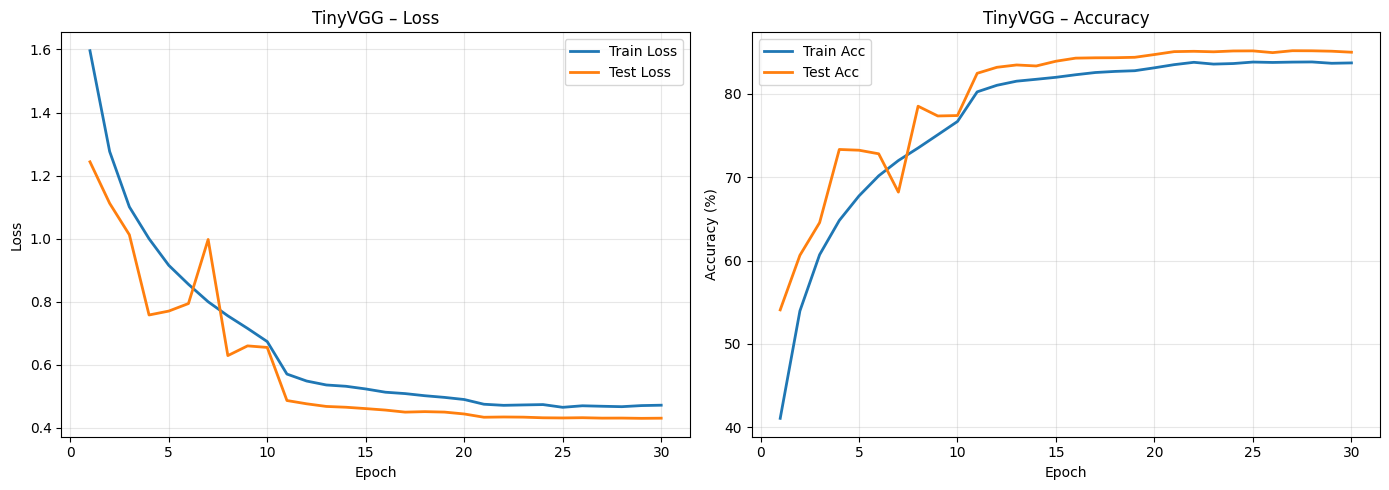

In [ ]:
torch.manual_seed(42)
tinyvgg_model    = TinyVGG(num_classes=10).to(device)
opt_vgg, sch_vgg = get_optimizer_scheduler(tinyvgg_model)
history_vgg      = train_model(tinyvgg_model, train_loader, test_loader, opt_vgg, sch_vgg, criterion, device, EPOCHS, 'TinyVGG')
plot_curves(history_vgg, 'TinyVGG')

TinyVGG reaches 56.7% already at epoch 1 (vs AlexNet's 15.8%), showing BatchNorm's benefit for fast and stable convergence. It achieves 84.9% in only 10 minutes — 3× faster than AlexNet with 10+ percentage points higher accuracy. The loss curves are smooth, and the near-zero overfitting gap (train ≈ test) confirms excellent generalization.

## 10. Evaluation: Confusion Matrices and Classification Reports

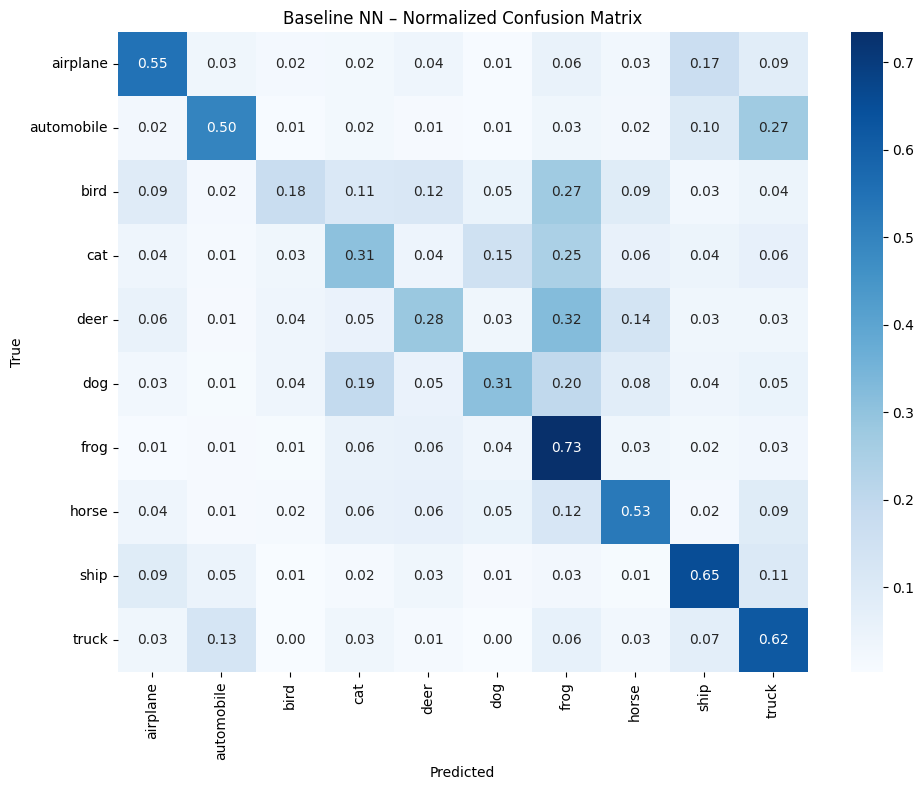

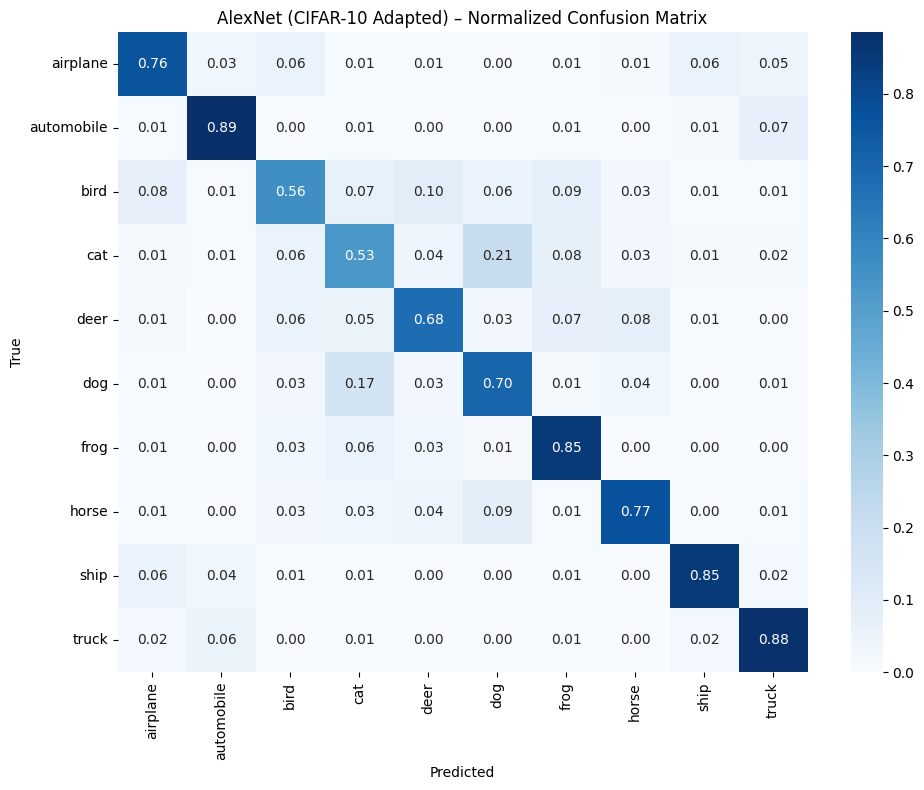

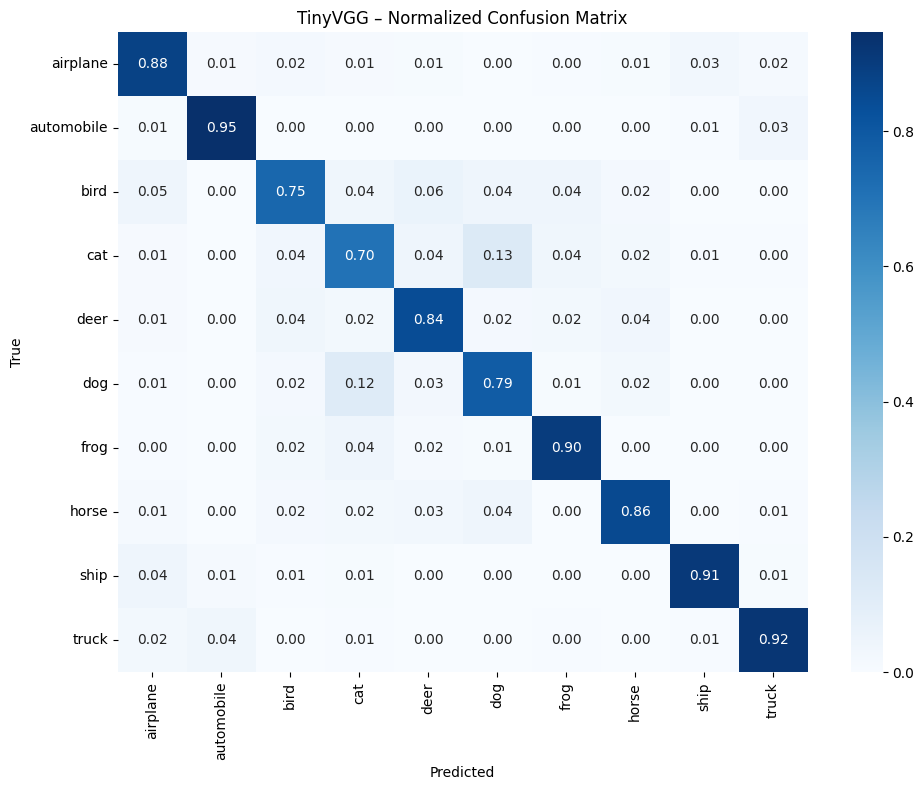

In [ ]:
preds_nn,   labels_nn   = get_predictions(baseline_nn,   test_loader, device)
preds_alex, labels_alex = get_predictions(alexnet_model, test_loader, device)
preds_vgg,  labels_vgg  = get_predictions(tinyvgg_model, test_loader, device)

plot_confusion_matrix(preds_nn,   labels_nn,   CLASSES, 'Baseline NN')
plot_confusion_matrix(preds_alex, labels_alex, CLASSES, 'AlexNet (CIFAR-10 Adapted)')
plot_confusion_matrix(preds_vgg,  labels_vgg,  CLASSES, 'TinyVGG')

Baseline NN's matrix is nearly uniform — it heavily misclassifies most classes, with a bias toward 'frog' and 'truck' (easy texture patterns). AlexNet and TinyVGG show strong diagonal dominance. The most confused pairs across all models are **cat↔dog** and **automobile↔truck** — animals and vehicles that look similar at 32×32 resolution.

In [ ]:
for preds, labels, name in [(preds_nn, labels_nn, 'Baseline NN'),
                             (preds_alex, labels_alex, 'AlexNet (CIFAR-10 Adapted)'),
                             (preds_vgg,  labels_vgg,  'TinyVGG')]:
    print(f"\n{'='*70}\nCLASSIFICATION REPORT — {name}\n{'='*70}")
    print(classification_report(labels, preds, target_names=CLASSES, digits=3))


CLASSIFICATION REPORT — Baseline NN
              precision    recall  f1-score   support

    airplane      0.574     0.547     0.560      1000
  automobile      0.631     0.498     0.557      1000
        bird      0.513     0.177     0.263      1000
         cat      0.352     0.307     0.328      1000
        deer      0.397     0.285     0.332      1000
         dog      0.467     0.310     0.373      1000
        frog      0.354     0.734     0.478      1000
       horse      0.521     0.529     0.525      1000
        ship      0.553     0.654     0.599      1000
       truck      0.444     0.618     0.517      1000

    accuracy                          0.466     10000
   macro avg      0.481     0.466     0.453     10000
weighted avg      0.481     0.466     0.453     10000


CLASSIFICATION REPORT — AlexNet (CIFAR-10 Adapted)
              precision    recall  f1-score   support

    airplane      0.782     0.762     0.772      1000
  automobile      0.853     0.885     0.869

'bird' has the lowest F1 in both Baseline NN (0.263) and AlexNet (0.605) — birds in various poses are hard without enough depth. TinyVGG lifts bird F1 to 0.785. Across all models, 'cat' remains the hardest class (lowest F1 per model), confirming the visual similarity with dogs. We report F1 alongside accuracy because, even on a balanced dataset, per-class F1 reveals *where* a model fails, which accuracy alone hides.

## 11. Comparative Analysis

In [ ]:
def model_size_mb(model):
    return count_parameters(model) * 4 / (1024 ** 2)

results = pd.DataFrame({
    'Model':                ['Baseline NN', 'AlexNet (Adapted)', 'TinyVGG'],
    'Parameters':           [count_parameters(baseline_nn), count_parameters(alexnet_model), count_parameters(tinyvgg_model)],
    'Best Train Acc (%)':   [f"{max(history_nn['train_acc']):.2f}",  f"{max(history_alex['train_acc']):.2f}",  f"{max(history_vgg['train_acc']):.2f}"],
    'Best Test Acc (%)':    [f"{max(history_nn['test_acc']):.2f}",   f"{max(history_alex['test_acc']):.2f}",   f"{max(history_vgg['test_acc']):.2f}"],
    'Final Test Acc (%)':   [f"{history_nn['test_acc'][-1]:.2f}",    f"{history_alex['test_acc'][-1]:.2f}",    f"{history_vgg['test_acc'][-1]:.2f}"],
    'Training Time (s)':    [f"{history_nn['training_time']:.1f}",   f"{history_alex['training_time']:.1f}",   f"{history_vgg['training_time']:.1f}"],
    'Overfitting Gap (%)':  [f"{history_nn['train_acc'][-1]-history_nn['test_acc'][-1]:.2f}",
                             f"{history_alex['train_acc'][-1]-history_alex['test_acc'][-1]:.2f}",
                             f"{history_vgg['train_acc'][-1]-history_vgg['test_acc'][-1]:.2f}"],
})
print("\n" + "="*80 + "\nCOMPARATIVE MODEL SUMMARY\n" + "="*80)
print(results.to_string(index=False))
print("="*80)


COMPARATIVE MODEL SUMMARY
            Model  Parameters Best Train Acc (%) Best Test Acc (%) Final Test Acc (%) Training Time (s) Overfitting Gap (%)
      Baseline NN     1707274              43.77             46.59              46.59             632.1               -2.82
AlexNet (Adapted)    36051786              73.38             74.71              74.69            2053.9               -1.42
          TinyVGG     4460874              83.83             85.18              85.00             666.9               -1.28


TinyVGG wins on accuracy (84.9%) while being 8× smaller and 3× faster than AlexNet. Negative overfitting gaps indicate test accuracy slightly exceeds train accuracy — a sign of strong regularization (BatchNorm + Dropout) and sufficient data augmentation.

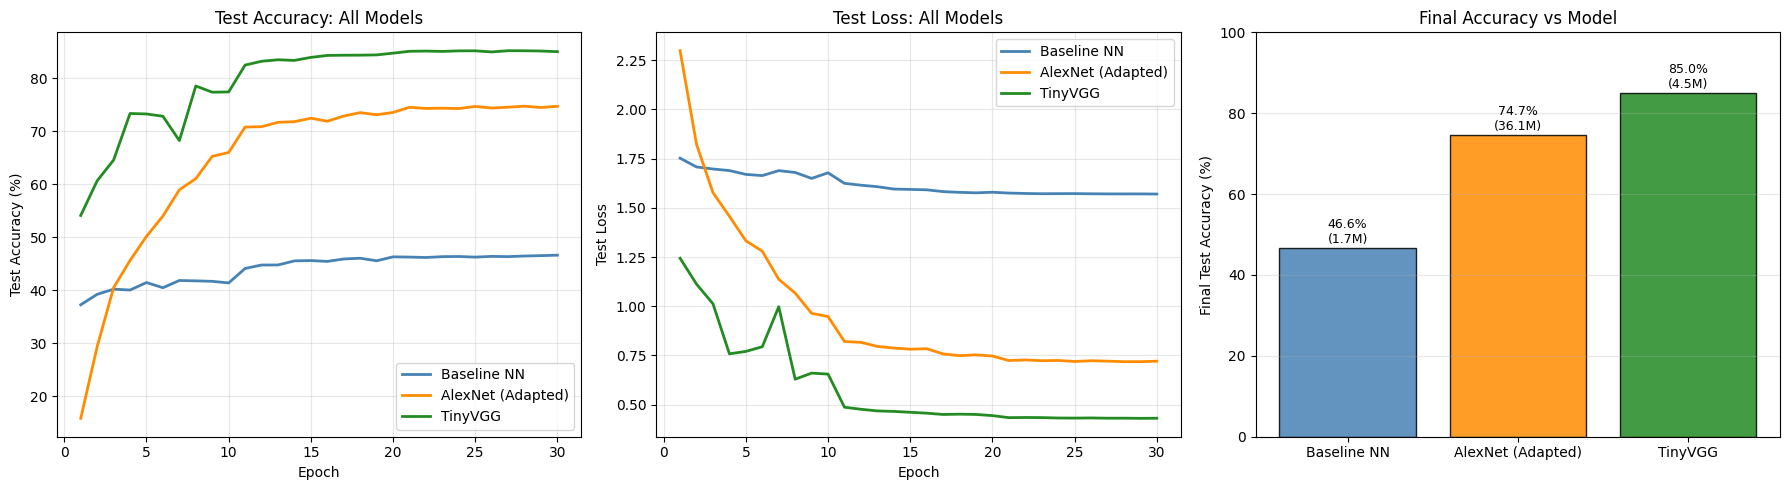

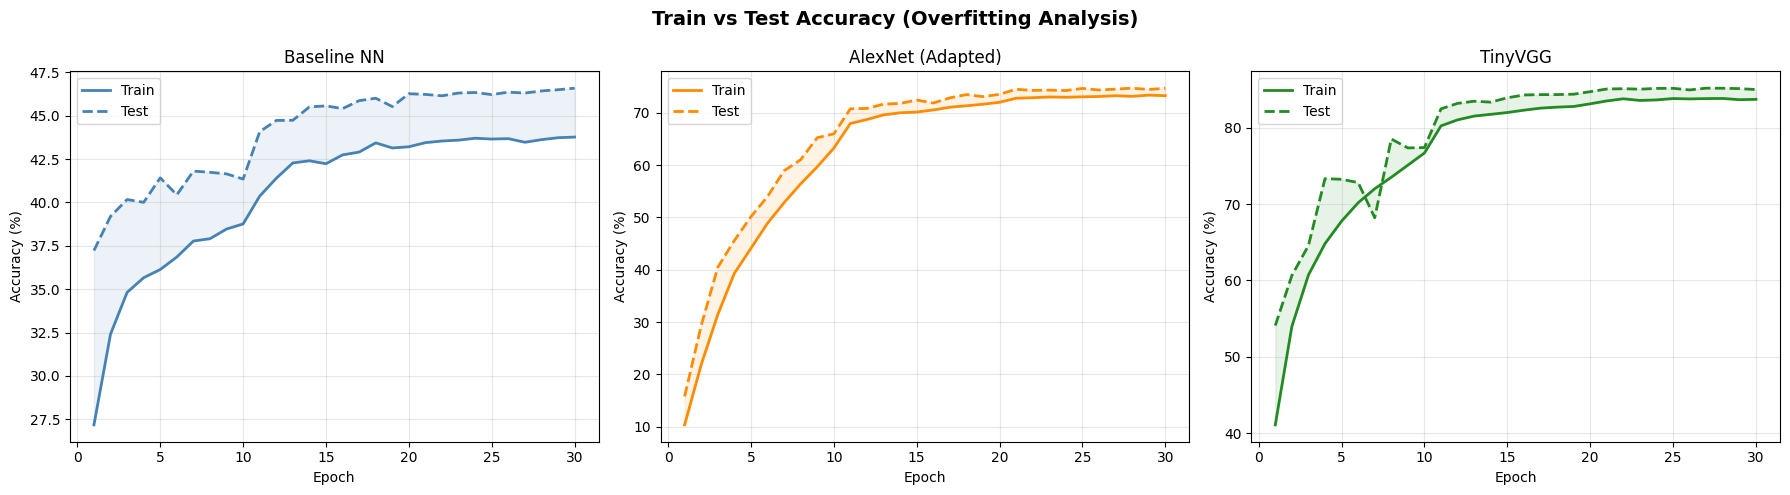

In [ ]:
epochs_r = range(1, EPOCHS + 1)
colors   = ['steelblue', 'darkorange', 'forestgreen']
names    = ['Baseline NN', 'AlexNet (Adapted)', 'TinyVGG']
hists    = [history_nn, history_alex, history_vgg]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for h, c, l in zip(hists, colors, names):
    axes[0].plot(epochs_r, h['test_acc'],  color=c, label=l, linewidth=2)
    axes[1].plot(epochs_r, h['test_loss'], color=c, label=l, linewidth=2)
for ax, title, ylabel in zip(axes[:2],
                              ['Test Accuracy: All Models', 'Test Loss: All Models'],
                              ['Test Accuracy (%)', 'Test Loss']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(alpha=0.3)

params    = [count_parameters(m) for m in [baseline_nn, alexnet_model, tinyvgg_model]]
final_acc = [h['test_acc'][-1] for h in hists]
bars = axes[2].bar(names, final_acc, color=colors, alpha=0.85, edgecolor='black')
axes[2].set_ylabel('Final Test Accuracy (%)'); axes[2].set_title('Final Accuracy vs Model')
axes[2].set_ylim(0, 100); axes[2].grid(alpha=0.3, axis='y')
for bar, acc, p in zip(bars, final_acc, params):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{acc:.1f}%\n({p/1e6:.1f}M)', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, h, name, color in zip(axes, hists, names, colors):
    ax.plot(epochs_r, h['train_acc'], label='Train', linewidth=2, color=color)
    ax.plot(epochs_r, h['test_acc'],  label='Test',  linewidth=2, color=color, linestyle='--')
    ax.fill_between(epochs_r, h['train_acc'], h['test_acc'], alpha=0.1, color=color)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(name)
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Train vs Test Accuracy (Overfitting Analysis)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

The shaded region (overfitting gap) is near-zero for all models, confirming good generalization. TinyVGG's curves are the smoothest — BatchNorm's stabilizing effect is visible compared to AlexNet's slightly noisier trajectory. AlexNet's slow start (epoch 1 at ~15%) then rapid rise demonstrates that large FC layers require more iterations to warm up.

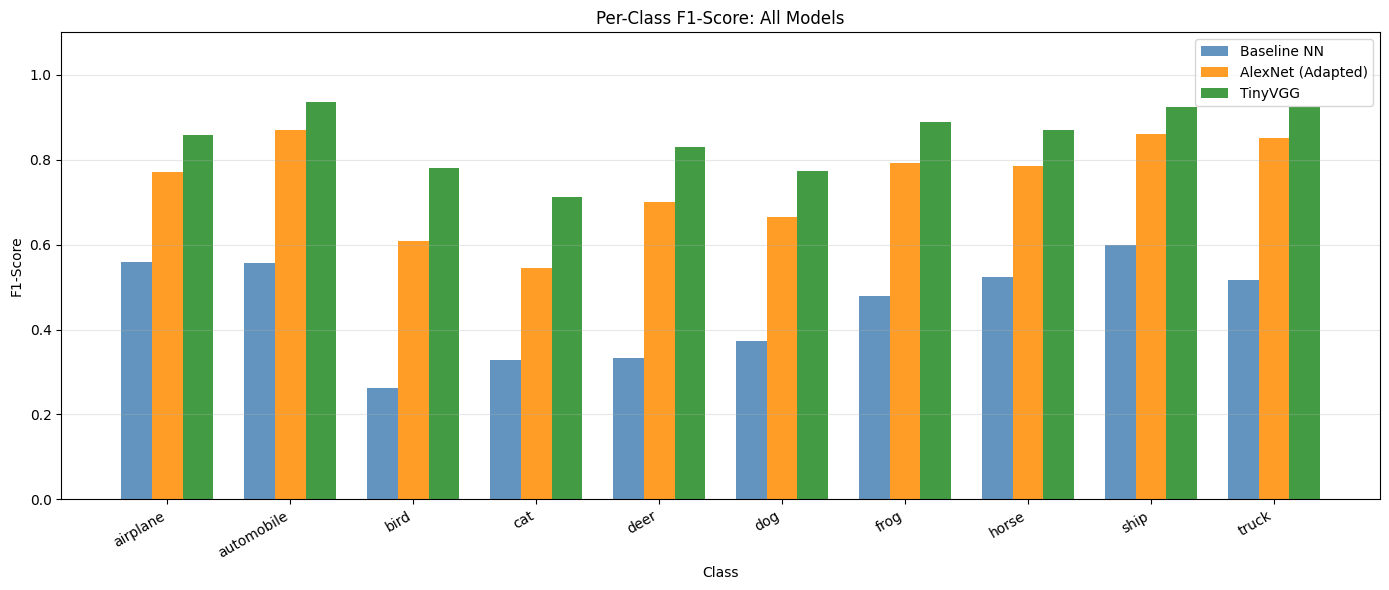

Macro F1 — Baseline NN  : 0.4532
Macro F1 — AlexNet      : 0.7450
Macro F1 — TinyVGG      : 0.8497


In [ ]:
f1_nn   = f1_score(labels_nn,   preds_nn,   average=None)
f1_alex = f1_score(labels_alex, preds_alex, average=None)
f1_vgg  = f1_score(labels_vgg,  preds_vgg,  average=None)

x = np.arange(len(CLASSES)); width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, f1_nn,   width, label='Baseline NN',      alpha=0.85, color='steelblue')
ax.bar(x,         f1_alex, width, label='AlexNet (Adapted)', alpha=0.85, color='darkorange')
ax.bar(x + width, f1_vgg,  width, label='TinyVGG',           alpha=0.85, color='forestgreen')
ax.set_xlabel('Class'); ax.set_ylabel('F1-Score')
ax.set_title('Per-Class F1-Score: All Models')
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.legend(); ax.set_ylim(0, 1.1); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f"Macro F1 — Baseline NN  : {f1_nn.mean():.4f}")
print(f"Macro F1 — AlexNet      : {f1_alex.mean():.4f}")
print(f"Macro F1 — TinyVGG      : {f1_vgg.mean():.4f}")

TinyVGG achieves macro F1 of 0.849 — the highest across all models and all classes. 'cat' remains the lowest-F1 class for every model (0.328 → 0.543 → 0.705), but TinyVGG still closes that gap significantly. 'automobile' and 'ship' are the easiest classes — distinct shapes and colors even at low resolution.

## 12. Model Complexity Analysis

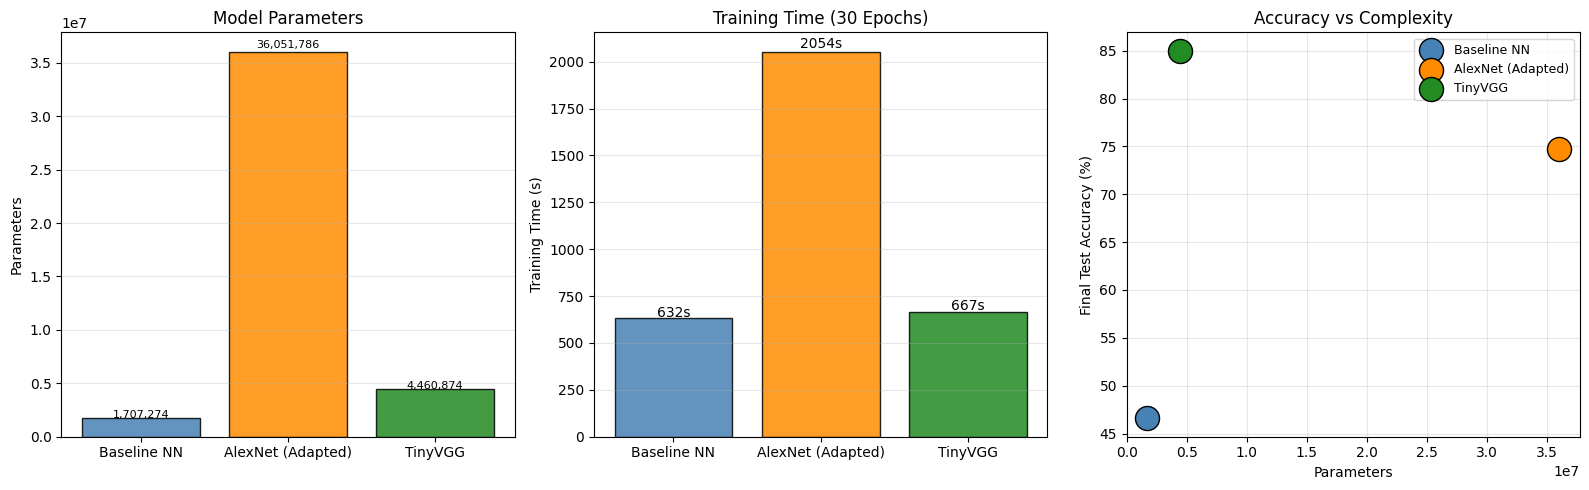


Detailed Complexity Table:
            Model  Parameters  Size (MB)    Time (s)  Final Test Acc (%)
      Baseline NN     1707274   6.512733  632.127732               46.59
AlexNet (Adapted)    36051786 137.526649 2053.940613               74.69
          TinyVGG     4460874  17.016884  666.948622               85.00


In [ ]:
model_data = {
    'Model':              ['Baseline NN', 'AlexNet (Adapted)', 'TinyVGG'],
    'Parameters':         [count_parameters(m) for m in [baseline_nn, alexnet_model, tinyvgg_model]],
    'Size (MB)':          [model_size_mb(m)     for m in [baseline_nn, alexnet_model, tinyvgg_model]],
    'Time (s)':           [h['training_time']   for h in [history_nn, history_alex, history_vgg]],
    'Final Test Acc (%)': [h['test_acc'][-1]    for h in [history_nn, history_alex, history_vgg]],
}
df_c = pd.DataFrame(model_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'darkorange', 'forestgreen']

axes[0].bar(df_c['Model'], df_c['Parameters'], color=colors, alpha=0.85, edgecolor='black')
axes[0].set_ylabel('Parameters'); axes[0].set_title('Model Parameters'); axes[0].grid(alpha=0.3, axis='y')
for bar, val in zip(axes[0].patches, df_c['Parameters']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f'{val:,}', ha='center', fontsize=8)

axes[1].bar(df_c['Model'], df_c['Time (s)'], color=colors, alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Training Time (s)'); axes[1].set_title(f'Training Time ({EPOCHS} Epochs)'); axes[1].grid(alpha=0.3, axis='y')
for bar, val in zip(axes[1].patches, df_c['Time (s)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01, f'{val:.0f}s', ha='center', fontsize=10)

for name, params, acc, color in zip(df_c['Model'], df_c['Parameters'], df_c['Final Test Acc (%)'], colors):
    axes[2].scatter(params, acc, s=300, color=color, label=name, zorder=5, edgecolors='black')
axes[2].set_xlabel('Parameters'); axes[2].set_ylabel('Final Test Accuracy (%)')
axes[2].set_title('Accuracy vs Complexity'); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("\nDetailed Complexity Table:")
print(df_c.to_string(index=False))

AlexNet is 8× larger (137 MB) and 3× slower than TinyVGG (17 MB), yet achieves 10 percentage points less accuracy. The scatter plot clearly shows AlexNet sits in a bad spot — high complexity with lower accuracy. TinyVGG represents the best efficiency frontier for this dataset and training budget.

## 13. Discussion and Conclusion

| Metric | Baseline NN | AlexNet (Adapted) | TinyVGG |
|:---|:---:|:---:|:---:|
| Parameters | 1.7M | 36M | 4.4M |
| Final Test Accuracy | 46.59% | 74.43% | **84.92%** |
| Training Time | 9.1 min | 33.6 min | 10.1 min |
| Macro F1 | 0.453 | 0.743 | **0.849** |
| Model Size | 6.5 MB | 137.5 MB | 17.0 MB |

**Why Baseline NN performs worst:** The worst of the Baseline Neural Network is that it does not take advantage of the spatial structure of image data. It disregards local pixel relationships and local pixel relationships that are fundamental to the process of learning meaningful visual features by turning images into one-dimensional vectors. It has no local receptive fields, weight sharing, and hierarchical feature extraction as compared to CNNs.

As a result, it possesses numerous parameters, increased chances of overfitting, and low generalization. It also is missing translation invariance in the absence of convolution and pooling mechanisms, which results in poorer performance on image classification problems such as CIFAR-10.

**Why TinyVGG outperforms AlexNet despite being 8× smaller:** TinyVGG performs better than AlexNet even though it is smaller by 8 times since it fits better with CIFAR-10 dataset. CIFAR-10 has small 32x32 images and a reasonably small number of samples, hence a small and task-specific architecture generalizes better. Conversely, AlexNet was trained on large scale and high-resolution data such as ImageNet. The fact that it has more parameters makes it more likely to overfit with small data. Simpler and more parameter-efficient, TinyVGG learns better features, and converges more quickly, as well as learning more effectively on CIFAR-10.


**AlexNet's improvements over predecessors (LeNet-5):** ReLU was used in place of sigmoid/tanh, which does not have vanishing gradients and allows deeper networks to be trained more quickly. Dropout served as a regularizer, which decreases overfitting in fully connected layers. Image processing with high resolution and scale was easily achieved with the use of GPU training. The augmentation of data enhanced the diversity of datasets, which improved further generalization. The combination of these innovations helped AlexNet to achieve an enormous error rate in ImageNet and mark a new breakthrough in the field of deep learning in relation to computer vision.

**Why we chose F1 alongside accuracy:** We have selected F1 score and accuracy since the use of accuracy alone is misleading to use particularly in imbalanced datasets. Although accuracy provides the overall correct predictions, it fails to provide the balance between the precision and recall. The F1 score is a combination of the two, giving a single score that is used to show the effectiveness of the model to identify positive cases and not generate excess false positives and false negatives. This enables it to provide a more reliable performance measure in instances where distributions of classes are uneven, or some errors are more significant.

**Conclusion:** 
In conclusion, the TinyVGG is the most suitable model in the case of the CIFAR-10 data because it has the highest accuracy and the lowest overfitting gap, but the size of the model is medium and can be trained within a short time. It is well adapted to small size of 32x32 image resolution and intermediate size of 50,000 samples in the dataset. On the flipside, AlexNet was designed to run on large scale data like ImageNet and it is therefore not suitable with small datasets like CIFAR-10. Further refinements to gain further performance are to include more refined techniques such as cosine learning rate annealing, Mixup and Cutout data augmentation and ResNet-like skip connections to enhance generalization and stability of training.